# Phase 3 Unsupervised Learning 

### Data preparation

In [1]:
import joblib
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import Normalizer
from sklearn.metrics import silhouette_score, confusion_matrix
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1️⃣ Load preprocessed features
# ------------------------------------------------------------
data = joblib.load("artifacts/feature_data.joblib")

X_train = data["X_train"]
y_train = data["y_train"]

print("✅ Data loaded successfully")
print("X_train shape:", X_train.shape)

# ------------------------------------------------------------
# 2️⃣ Drop 'receiver_spam_ratio' column
# ------------------------------------------------------------
numeric_cols = [
    'urls', 'receiver_spam_ratio', 'hour',
    'capital_letter_count', 'capital_ratio',
    'exclamation_count', 'question_count', 'special_char_count',
    'day_of_week_Friday', 'day_of_week_Monday',
    'day_of_week_Saturday', 'day_of_week_Sunday',
    'day_of_week_Thursday', 'day_of_week_Tuesday',
    'day_of_week_Wednesday'
]

drop_idx = numeric_cols.index('receiver_spam_ratio')
num_cols_start = X_train.shape[1] - len(numeric_cols)
abs_idx = num_cols_start + drop_idx

X_train = X_train[:, np.arange(X_train.shape[1]) != abs_idx]
print("Dropped 'receiver_spam_ratio'")
print("New X_train shape:", X_train.shape)

# ------------------------------------------------------------
# 3️⃣ Dimensionality reduction
# ------------------------------------------------------------
svd = TruncatedSVD(n_components=5, random_state=42)
X_reduced = svd.fit_transform(X_train)

# ------------------------------------------------------------
# 4️⃣ Normalize data (helps TF-IDF with Euclidean distance)
# ------------------------------------------------------------
scaler = Normalizer()
X_normalized = scaler.fit_transform(X_reduced)

#normalizer = Normalizer()
#X_normalized = normalizer.fit_transform(X_reduced) جربت الكوزاين هنا بس مافرق نفس الناتج

✅ Data loaded successfully
X_train shape: (31311, 5015)
Dropped 'receiver_spam_ratio'
New X_train shape: (31311, 5014)


### Elbow method

Number of clusters = 2 --> Silhouette Score = 0.392
Number of clusters = 3 --> Silhouette Score = 0.534
Number of clusters = 4 --> Silhouette Score = 0.578
Number of clusters = 5 --> Silhouette Score = 0.572
Number of clusters = 6 --> Silhouette Score = 0.503
Number of clusters = 7 --> Silhouette Score = 0.499
Number of clusters = 8 --> Silhouette Score = 0.510
Number of clusters = 9 --> Silhouette Score = 0.441
Number of clusters = 10 --> Silhouette Score = 0.426


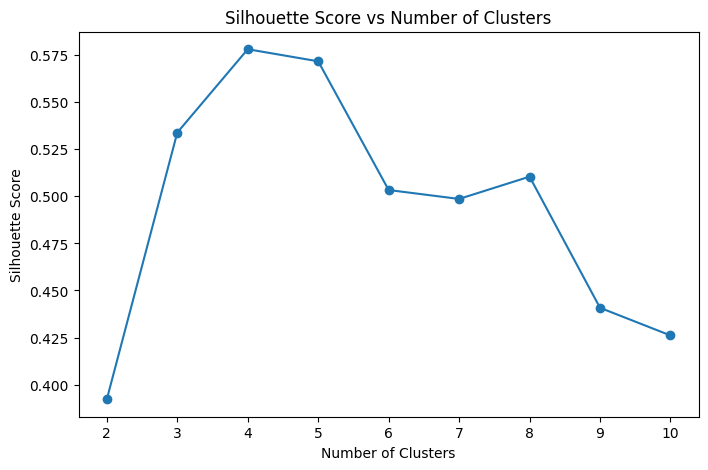

In [2]:
# ------------------------------------------------------------
# 5️⃣ Silhouette Score per number of clusters
# ------------------------------------------------------------
sil_scores = []
cluster_range = range(2, 11)  # من 2 إلى 10

for k in cluster_range:
    kmeans_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_tmp = kmeans_tmp.fit_predict(X_normalized)
    score = silhouette_score(X_normalized, labels_tmp)
    sil_scores.append(score)
    print(f"Number of clusters = {k} --> Silhouette Score = {score:.3f}")

# Plot Silhouette vs K
plt.figure(figsize=(8,5))
plt.plot(cluster_range, sil_scores, marker='o')
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(cluster_range)
plt.show()

### Training using k-means


Optimal number of clusters according to silhouette: 4
✅ K-Means trained with  optimal K
🧠 Final Silhouette Score: 0.578

Confusion Matrix (for analysis only):
[[3047  552 4190 6061]
 [2943 1191 6223 7104]
 [   0    0    0    0]
 [   0    0    0    0]]


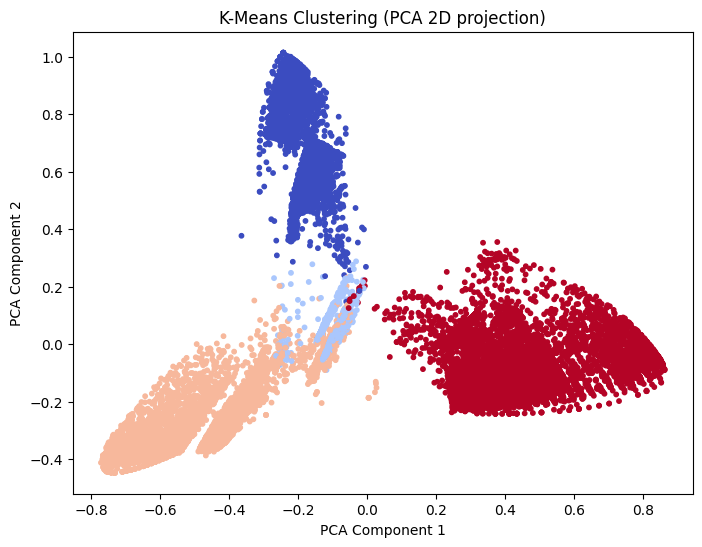


💾 K-Means model saved to artifacts/kmeans_model_phase3_improved.joblib


In [3]:
# ------------------------------------------------------------
# 6️⃣ Train K-Means with optimal K
# ------------------------------------------------------------
optimal_k = cluster_range[np.argmax(sil_scores)]
print(f"\nOptimal number of clusters according to silhouette: {optimal_k}")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_normalized)
print("✅ K-Means trained with  optimal K")

# ------------------------------------------------------------
# 7️⃣ Evaluate clustering
# ------------------------------------------------------------
final_sil_score = silhouette_score(X_normalized, cluster_labels)
print(f"🧠 Final Silhouette Score: {final_sil_score:.3f}")

cm = confusion_matrix(y_train, cluster_labels)
print("\nConfusion Matrix (for analysis only):")
print(cm)

# ------------------------------------------------------------
# 8️⃣ Visualization (PCA 2D)
# ------------------------------------------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_normalized)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap='coolwarm', s=10)
plt.title("K-Means Clustering (PCA 2D projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

# ------------------------------------------------------------
# 9️⃣ Save the trained model
# ------------------------------------------------------------
joblib.dump(kmeans, "artifacts/kmeans_model_phase3_improved.joblib")
print("\n💾 K-Means model saved to artifacts/kmeans_model_phase3_improved.joblib")
